In [1]:
"""
The purpose of this Jupyter notebook is to determine whether
control-based Z-scoring alleviates plate-to-plate variation or not. To
this end, a dimensionality reduction is performed by means of UMAP for
both cases, i.e. raw values and Z-scored values. Subsequently, it is
evaluated by eye whether the potential clustering by plate is alleviated
or not. As input to the UMAP algorithm, vectors are used containing the
raw and Z-scored values of the measurements, respectively (intensity
values and cell count).
"""

'\nThe purpose of this Jupyter notebook is to determine whether\ncontrol-based Z-scoring alleviates plate-to-plate variation or not. To\nthis end, a dimensionality reduction is performed by means of UMAP for\nboth cases, i.e. raw values and Z-scored values. Subsequently, it is\nevaluated by eye whether the potential clustering by plate is alleviated\nor not. As input to the UMAP algorithm, vectors are used containing the\nraw and Z-scored values of the measurements, respectively (intensity\nvalues and cell count).\n'

In [2]:
import os

import pandas as pd
import umap
from matplotlib import pyplot as plt

### Loading the Data Set

In [3]:
screen_subset_path = (
    "Dharmacon_pooled_G1_G2_screening_plates_subset_with_missing_"
    "UniProt_IDs_control-based_Z-scored.tsv"
)

screen_subset_df = pd.read_csv(
    screen_subset_path,
    sep="\t"
)

In [4]:
# Determine the unique control names
control_names = screen_subset_df.loc[
    screen_subset_df["WellType"] == "CONTROL",
    "Name"
].unique().tolist()

# Remove the "UNKNOWN" entry from the control names list
control_names.remove("UNKNOWN")

assert "UNKNOWN" not in control_names, (
    "Removal of the 'UNKNOWN' entry was not successful!"
)

In [5]:
print(control_names)

['ATP6V1A', 'SCRAMBLED', 'MOCK', 'PSMC3', 'KIF11', 'PSMA6', 'TSG101', 'GFP', 'RAC1', 'ARPC3', 'CDC42', 'PAK1']


### Per Control Reduction of Both Raw Values and Z-Scored Values

In [39]:
# For the sake of convenience, define a function performing the
# dimensionality reduction as well as the plot generation under the hood

def plot_reduced_dims(
        input_df, gene_list, feature_list, n_plates, image_dir,
        norm_method
):
    """
    Visualizes the presence or absence of batch effects/plate-to-plate
    variation by performing dimensionality reduction of measurements,
    followed by plotting as scatter plots.
    
    Dimensionality reduction is performed using the UMAP algorithm on
    the features specified in `feature_list`. Each control is reduced
    independently, rather than being pooled together.

    For each gene in `gene_list`, a scatter plot is generated
    visualizing the corresponding measurements for `n_plates` plates.
    Cluster formation of measurements belonging to one plate indicates
    the presence of batch effects, whereas an even distribution
    indicates the absence thereof.

    Each scatter plot is saved both as PNG and SVG.

    Parameters
    ----------
    input_df: Pandas DataFrame
        Pandas DataFrame storing the measurements to perform
        dimensionality reduction on.
    gene_names: list
        List containing the names of the genes to visualize.
    feature_list: list
        List containing the names of the features to perform
        dimensionality reduction on.
    n_plates: int
        Integer specifying the number of plates to visualize for each
        control.
    image_dir: str
        Name of the directory to store the scatter plots in.
    norm_method: str
        A string denoting the normalization method applied to the data
        to perform dimensionality reduction on. The normalization
        method's name appears in the figure title.

    Returns
    -------
    None
    """

    # Create the directory to store the scatter plots in in case it does
    # not already exist
    if not os.path.exists(image_dir):
        os.makedirs(image_dir)
    
    # Determine the unique plate barcodes present in the input DataFrame
    # Conveniently enough, Pandas's `.unique()` method does not sort,
    # but lists the unique values in order of appearance
    unique_plate_barcodes = input_df["Barcode"].unique()

    # Iterate over the list of gene names, extract the corresponding
    # subset from the DataFrame and perform dimensionality reduction
    # At the same time, gather the barcode series for each gene
    reducer = umap.UMAP(random_state=0)
    reduced_embs_per_control = []
    barcode_array_per_gene = []

    for gene_name in gene_list:
        gene_subset = input_df.loc[
            input_df["Name"] == gene_name,
            feature_list
        ]

        reduced_embs_per_control.append(
            reducer.fit_transform(gene_subset)
        )

        barcode_array_per_gene.append(
            input_df.loc[
                input_df["Name"] == gene_name,
                "Barcode"
            ].to_numpy()
        )
    
    # For each gene, plot the first `n_plates` plates
    N_PLATES = n_plates

    colors = plt.get_cmap("tab10").colors

    for gene_name, reduced_embs, barcode_array in zip(
        gene_list,
        reduced_embs_per_control,
        barcode_array_per_gene
    ):
        fig, ax = plt.subplots(1, 1)

        # Extract the embeddings of the corresponding plate
        for barcode, color in zip(
            unique_plate_barcodes[:N_PLATES],
            colors[:N_PLATES]
        ):
            current_plate_embs = reduced_embs[
                barcode_array == barcode
            ]

            # Plot the embeddings of the current plate with a distinct
            # color
            ax.scatter(
                current_plate_embs[:, 0],
                current_plate_embs[:, 1],
                color=color,
                label=barcode
            )
        ax.legend(
            loc="best",
            fontsize=13
        )
        ax.set_title(
            f"Plate-to-plate variation for control\n{gene_name} ({norm_method})",
            fontsize=20
        )

        ax.set_xlabel("UMAP 1", fontsize=18)
        ax.set_ylabel("UMAP 2", fontsize=18)

        ax.tick_params(axis="both", labelsize=13)

        fig.savefig(
            os.path.join(
                image_dir,
                f"plate-to-plate_variation_control_{gene_name}_{norm_method}.png"
            ),
            dpi=300
        )

        fig.savefig(
            os.path.join(
                image_dir,
                f"plate-to-plate_variation_control_{gene_name}_{norm_method}.svg"
            )
        )

In [40]:
# Define the unnormalized features
unnormalized_features_list = [
    "eCount_oCells",
    "dIntensity_cPathogen_eMean_oNuclei",
    "dIntensity_cPathogen_eMean_oPeriNuclei",
    "dIntensity_cPathogen_eMean_oCells",
    "dIntensity_cPathogen_eMean_oVoronoiCells",
    "dIntensity_cLatePathogen_eMean_oNuclei",
    "dIntensity_cLatePathogen_eMean_oPeriNuclei",
    "dIntensity_cLatePathogen_eMean_oCells",
    "dIntensity_cLatePathogen_eMean_oVoronoiCells"
]

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


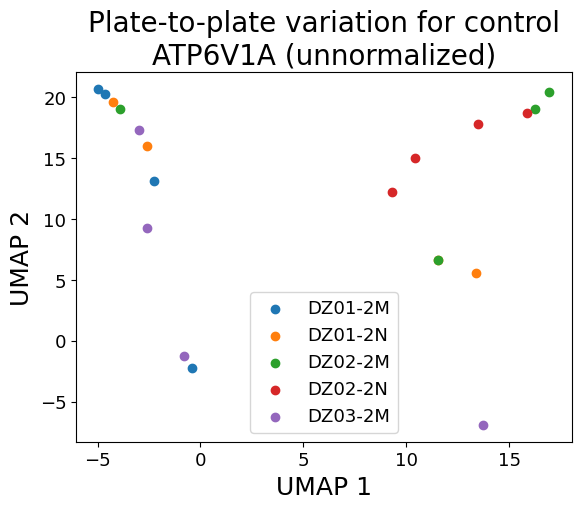

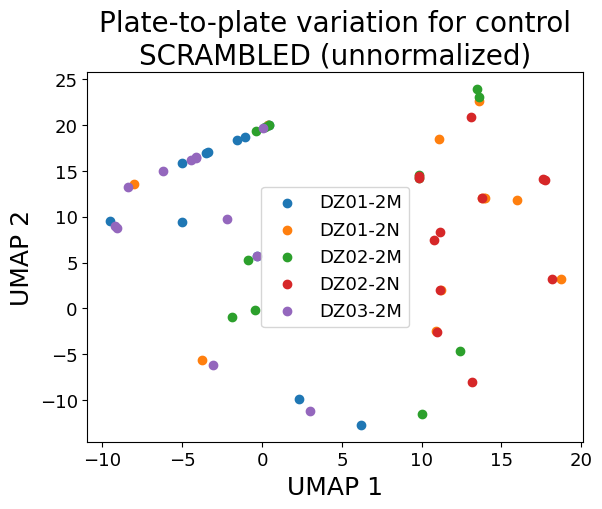

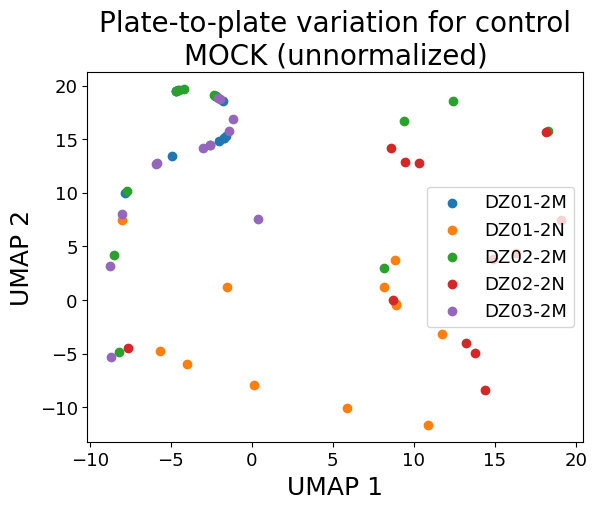

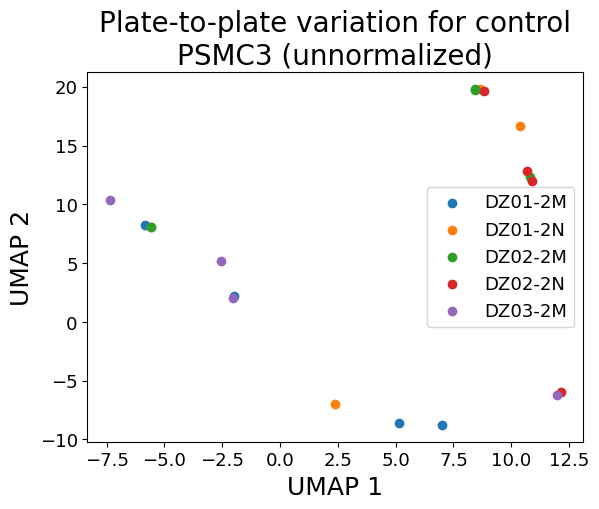

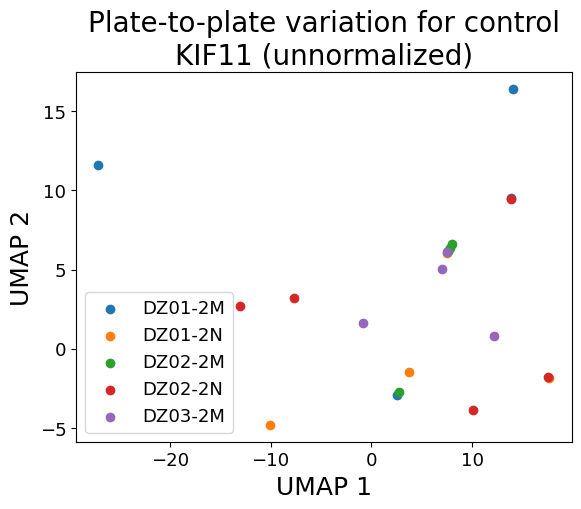

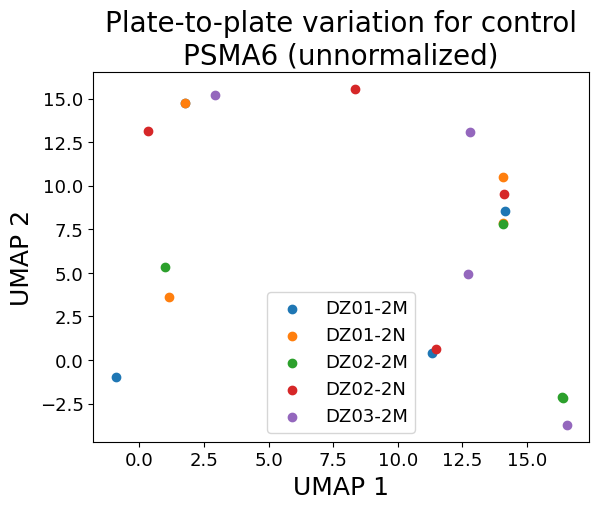

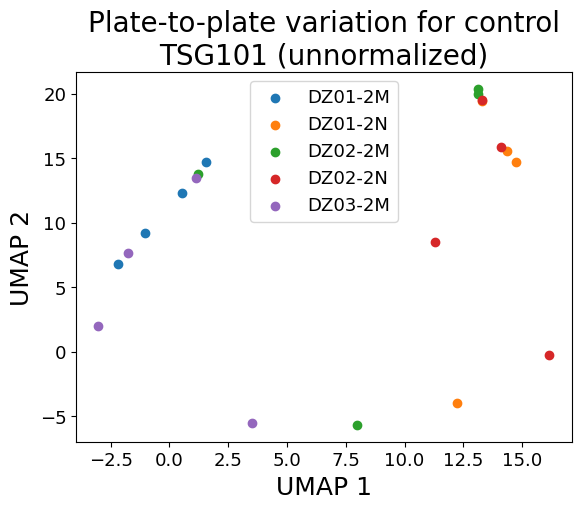

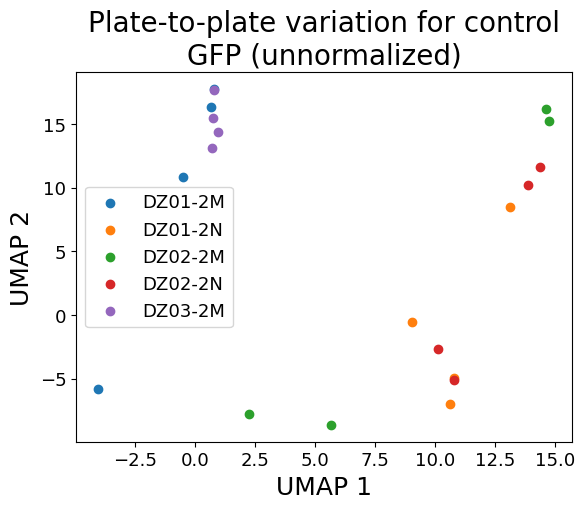

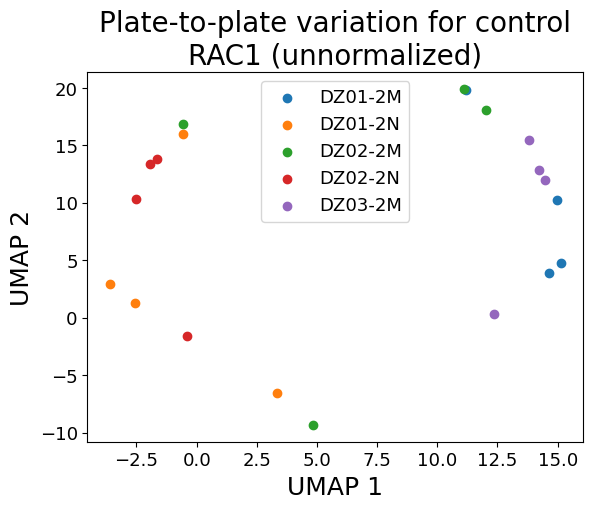

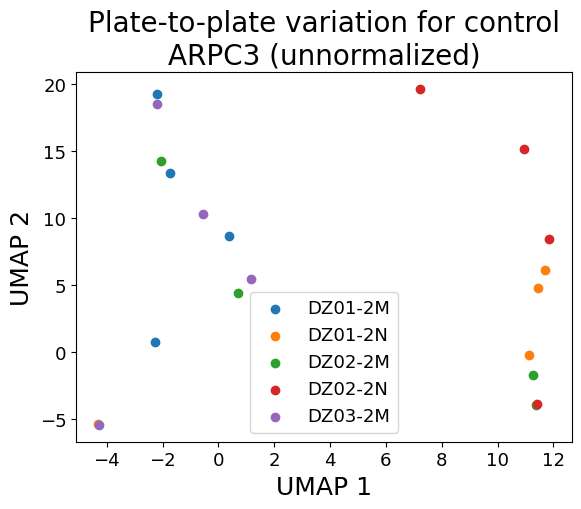

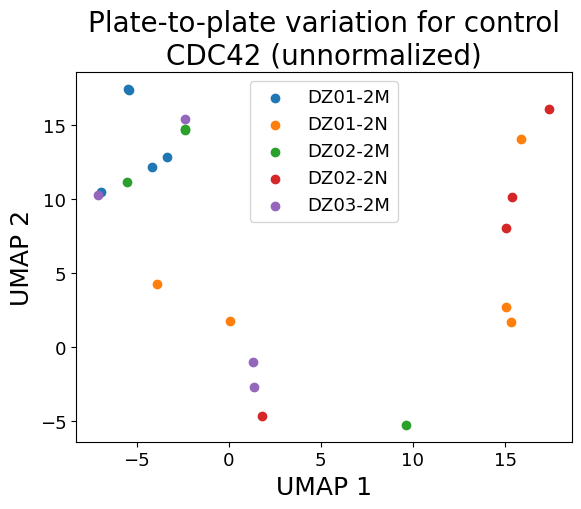

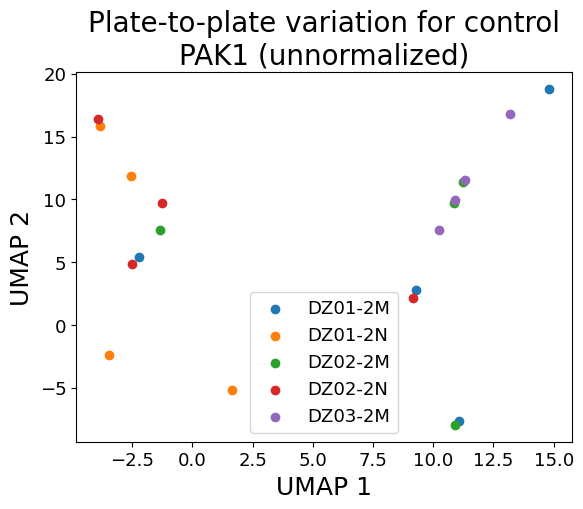

In [41]:
unnormalized_plots_path = os.path.join(
    "controls_UMAP_images",
    "images_unnormalized_vals_embs_reduction_per_control"
)

plot_reduced_dims(
    screen_subset_df,
    control_names,
    unnormalized_features_list,
    5,
    unnormalized_plots_path,
    "unnormalized"
)

### Per Control Reduction of Z-Scored Values

In [42]:
normalized_features_list = [
    unnormalized_feature + "_nZScore"
    for unnormalized_feature in unnormalized_features_list
]

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


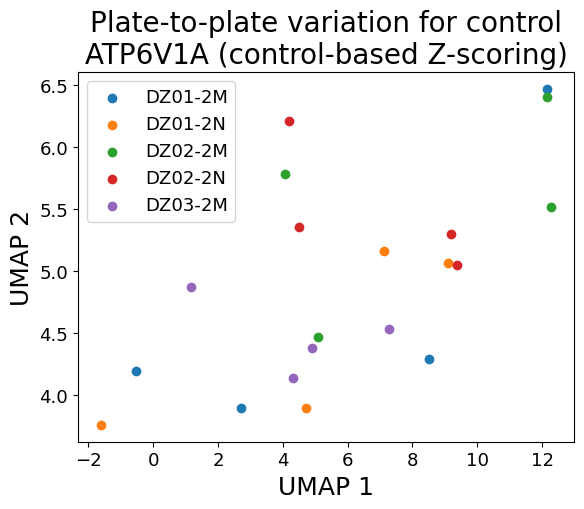

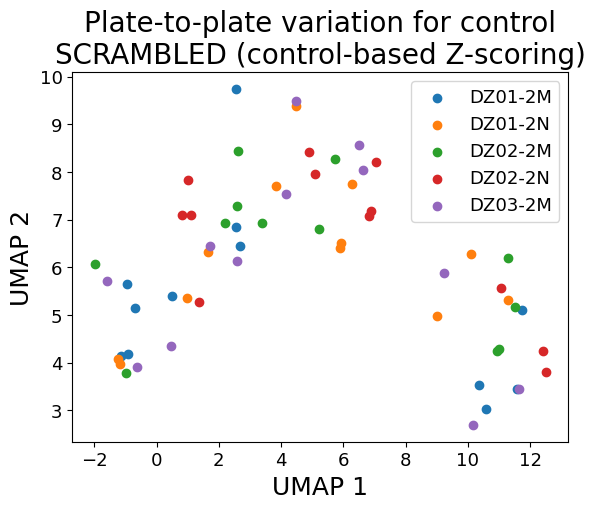

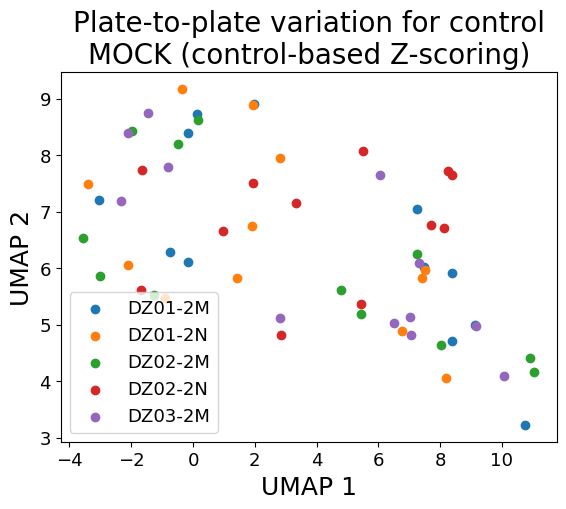

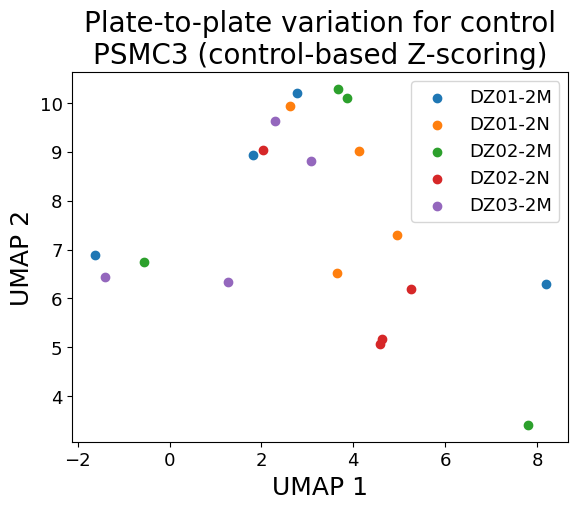

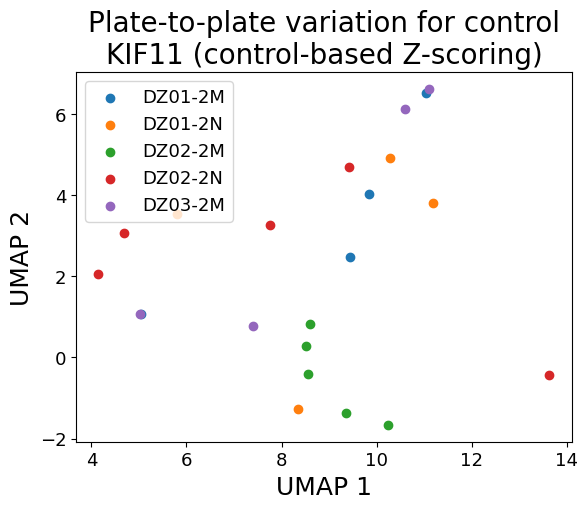

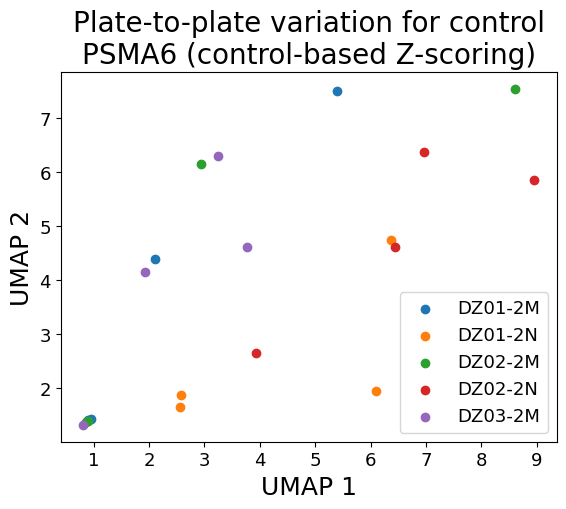

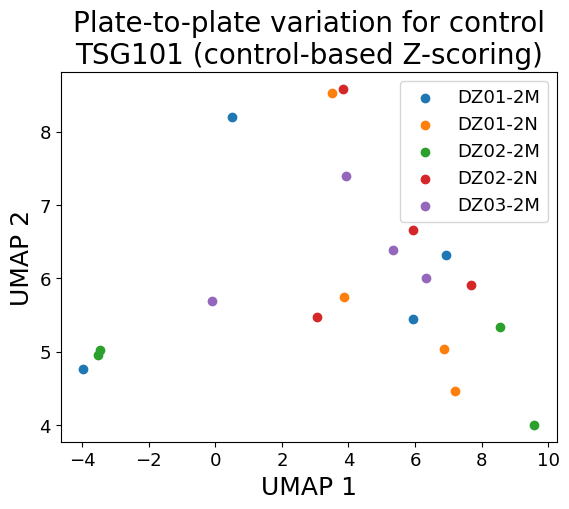

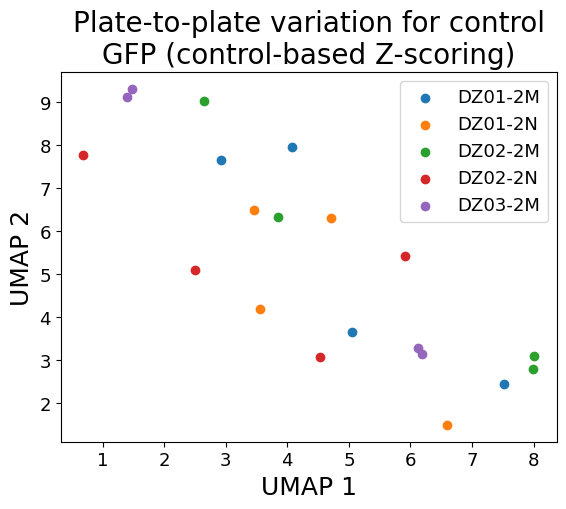

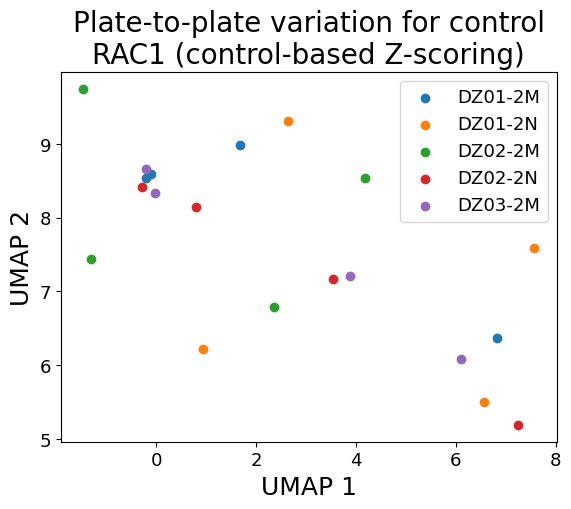

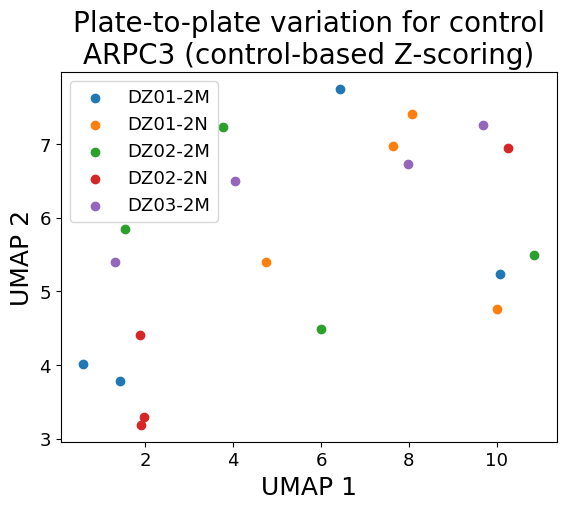

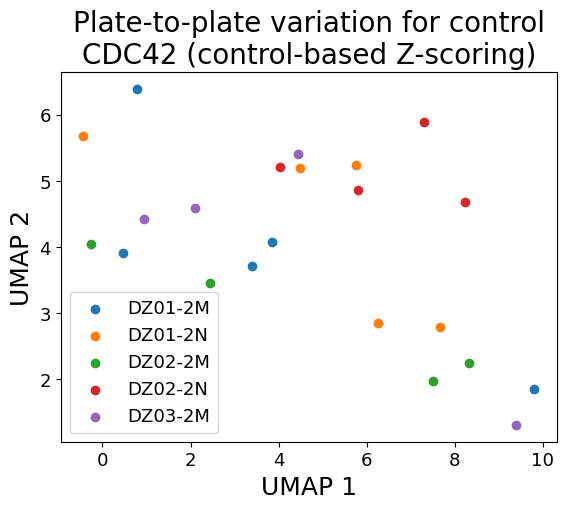

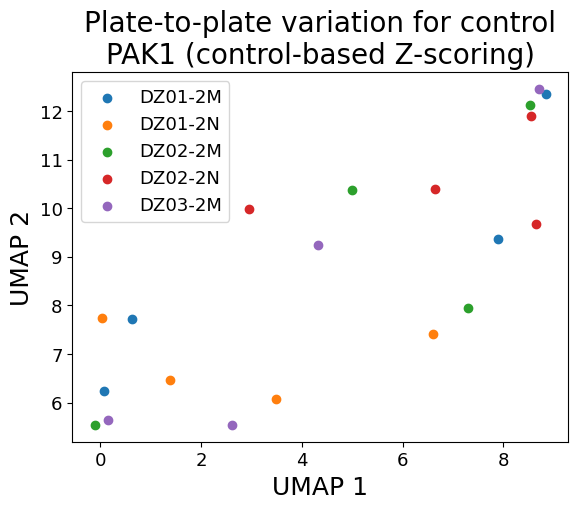

In [43]:
normalized_plots_path = os.path.join(
    "controls_UMAP_images",
    "images_control-based_Z-scored_vals_embs_reduction_per_control"
)

plot_reduced_dims(
    screen_subset_df,
    control_names,
    normalized_features_list,
    5,
    normalized_plots_path,
    "control-based Z-scoring"
)